# QCrank Encoding Python Version for Multi-Channel Audio - Statevector Retrieval

This notebook demonstrates how a short, multi-channel audio signal with amplitudes in
$[-1,1]$ can be encoded into a quantum state using parallel uniformly controlled
$R_y$ circuits. It then decodes the ideal statevector and compares the reconstructed
samples in every channel with the original signal.

> **Academic Acknowledgement**  
> QCrank was introduced by **Jan Balewski, Mercy G. Amankwah, Roel Van Beeumen,
> E. Wes Bethel, Talita Perciano, and Daan Camps** in *Quantum-parallel vectorized data
> encodings and computations on trapped-ion and transmon QPUs*, *Scientific Reports*
> **14**, 3435 (2024). DOI: [10.1038/s41598-024-53720-x](https://doi.org/10.1038/s41598-024-53720-x).
>
> **Software Acknowledgement**    
> Parts of the Walsh–Hadamard preprocessing, Gray-code circuit decomposition,
> and QCrank circuit construction in this notebook were adapted from the
> [HeidelbergQuantum/QPIXL_ITU-2025](https://github.com/HeidelbergQuantum/QPIXL_ITU-2025)
> repository by **Daniel Bultrini**. The source repository is open source and
> licensed for non-commercial use; commercial use requires separate
> permission or licensing from the owner.

## 1. Introduction: QCrank encoding state and workflow

- For each audio sample $x_{j,c}\in[-1,1]$ in channel $c$, the notebook defines the
  logical rotation angle
  $\phi_{j,c}=\frac{\pi}{2}(x_{j,c}+1)$, which maps $[-1,1]\mapsto[0,\pi]$.

- For $N=2^{n_a}$ samples and $n_d$ audio channels, the circuit uses:
    - $n_d$ **data qubits**, one per audio channel;
    - $n_a=\log_2N$ shared **address qubits**.

- The intended encoded state is

$$
|\psi\rangle=
\frac{1}{\sqrt{N}}
\sum_{j=0}^{N-1}
|j\rangle
\bigotimes_{c=0}^{n_d-1}
\left[
\cos\left(\frac{\phi_{j,c}}{2}\right)|0\rangle_c+
\sin\left(\frac{\phi_{j,c}}{2}\right)|1\rangle_c
\right].
$$

- For stereo audio, the two values at address $j$ are stored simultaneously:
  the left sample on one data qubit and the right sample on another data qubit.

- The notebook follows this sequence:

1. Generate a toy multi-channel audio signal
2. Map every channel's samples to logical $R_y$ angles
3. Transform those angles into uniformly controlled-rotation coefficients
4. Construct and simulate the parallel QCrank circuit
5. Recover every channel's angles from ideal marginal probabilities
6. Map the angles back to audio amplitudes
7. Compare the original and decoded channels

**NOTE:** the logical angles $\phi_{j,c}$ are not generally the individual
$R_y$ angles visible in the decomposed circuit. The visible rotations are transformed
coefficients whose signed combinations reproduce the logical angles for every address
and channel.

## 2. Imports


In [1]:
# Numerical arrays and mathematical operations
import numpy as np

# Plotting the original and reconstructed signals
import matplotlib.pyplot as plt

# Notebook display helper for the Matplotlib circuit drawing
from IPython.display import display

# Qiskit circuit construction and exact statevector simulation
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Audio playback in Jupyter notebooks
from IPython.display import Audio

## 3. Classical preprocessing functions

### 3.1 Binary functions


In [2]:
def is_power_of_two(n): # Checks if the signal length is power of two
    """Return True when ``n`` is a positive integer power of two."""
    # A positive power of two contains exactly one set/activated bit. Clearing its
    # lowest set bit with n & (n - 1) therefore produces zero.
    # Example: 8 = 1000, 8 - 1 = 7 = 0111, and 8 & 7 = 0.
    # Bitwise AND (&): 11=1; 10,01,00=0.
    return n > 0 and (n & (n - 1)) == 0


def gray_code(value): # Converts a non-negative integer to binary-reflected Gray code
    """Return the binary-reflected Gray code of a non-negative integer."""
    # g(i) = i XOR (i shifted right by one bit). Consecutive Gray-code words differ
    # in exactly one bit: 00->01->11->10 = 0->1->3->2.
    # Example: g(2) = 2 ^ (2 >> 1) = 2 ^ 1 = 3.
    # Bitwise XOR (^): 11,00=0; 10,01=1.
    return value ^ (value >> 1)


def count_trailing_zeros(value):
    # Returns the index of the least-significant set/activated bit.
    """Return the index of the least-significant set bit in ``value``."""
    if value <= 0:
        raise ValueError("value must be a positive integer")

    # value & -value isolates the least-significant set/activated bit. Its bit
    # length, minus one, gives the zero-based bit position.
    # Example: value = 12 = 1100, value & -value = 0100, so index = 2.
    return (value & -value).bit_length() - 1

### 3.2 Scaled Fast Walsh–Hadamard transform and channel-dependent Gray permutations

Let $\boldsymbol{\phi}_{:,c}$ denote the vector of desired logical angles for
channel $c$. A compact uniformly controlled rotation uses transformed elementary
coefficients rather than the logical angles directly.

For the unpermuted channel, the familiar preprocessing is a scaled
Walsh–Hadamard transform followed by Gray-code reordering:

$$
\boldsymbol{\alpha}_{:,c}=\frac{1}{N}H_N\boldsymbol{\phi}_{:,c}.
$$

QCrank uses cyclically permuted Gray-code control sequences on different data
qubits. These permutations make CNOTs belonging to different channels act on
different address–data pairs, so they can be scheduled in parallel when the
pairs are disjoint.

The implementation below constructs the corresponding signed transform matrix
directly from each channel's CNOT sequence. This is mathematically the same
Walsh–Hadamard-type preprocessing, with the permutation appropriate to that
channel.

Compression, when requested, is applied to these transformed coefficients rather
than directly to the audio samples.

In [3]:
def _address_control_bit(step_index, number_of_address_qubits, shift=0):
    """
    Return the address-bit position controlling the CNOT after one RY rotation.

    Consecutive Gray-code words differ in one bit. ``shift`` cyclically permutes
    that control bit for a different data qubit.
    """
    n = 1 << number_of_address_qubits
    next_index = (step_index + 1) % n

    changed_bit = gray_code(step_index) ^ gray_code(next_index)
    bit_position = count_trailing_zeros(changed_bit)

    return (bit_position + shift) % number_of_address_qubits


def _ucr_sign_matrix(number_of_address_qubits, shift=0):
    """
    Build the signed Walsh-Hadamard-type matrix for one permuted compact UCRy.

    Each row represents one computational-basis address. Each column represents
    one elementary RY rotation in circuit order.
    """
    n = 1 << number_of_address_qubits
    matrix = np.empty((n, n), dtype=float)

    for address in range(n):
        target_x_parity = 0

        for step_index in range(n):
            matrix[address, step_index] = (
                -1.0 if target_x_parity else 1.0
            )

            control_bit = _address_control_bit(
                step_index,
                number_of_address_qubits,
                shift,
            )

            # The CNOT fires for this address when the selected address bit is 1.
            target_x_parity ^= (address >> control_bit) & 1

        # The cyclic Gray-code path must return the target to its original X parity.
        if target_x_parity != 0:
            raise RuntimeError("The cyclic Gray-code path did not close.")

    return matrix


def permuted_ucr_coefficients(
    target_angles,
    number_of_address_qubits,
    shift=0,
):
    """
    Return compact-circuit RY coefficients for one channel.

    If M is the signed transform matrix, target_angles = M @ coefficients.
    Since M @ M.T = N I, the inverse is M.T / N.
    """
    target_angles = np.asarray(target_angles, dtype=float)
    n = 1 << number_of_address_qubits

    if target_angles.shape != (n,):
        raise ValueError(f"target_angles must contain exactly {n} values.")

    matrix = _ucr_sign_matrix(number_of_address_qubits, shift)
    return matrix.T @ target_angles / n

## 4. Audio-to-angle conversion

Every channel is mapped independently. The audio samples are linearly mapped from
$x\in[-1,1]$ to rotation angles $\phi\in[0,\pi]$ using $\phi=\frac{\pi}{2}(x+1), \quad x=\frac{2\phi}{\pi}-1.$

This interval is chosen so that each audio sample corresponds to a unique
measurement probability and can therefore be recovered without ambiguity.
Negative samples are represented by angles below $\pi/2$, zero corresponds to $\pi/2$, and positive samples are represented by angles above $\pi/2$: $ -1\mapsto0,\quad 0\mapsto\frac{\pi}{2},\quad 1\mapsto\pi.$

In [4]:
def audio_to_angles(audio):
    """Map finite mono or multi-channel audio in [-1, 1] to [0, pi]."""
    audio = np.asarray(audio, dtype=float)

    # Accept mono shape (N,) or multi-channel shape (N, number_of_channels).
    if audio.ndim not in (1, 2):
        raise ValueError(
            "audio must have shape (N,) or (N, number_of_channels)."
        )

    # Reject invalid floating-point values before constructing the circuit.
    if np.any(~np.isfinite(audio)):
        raise ValueError("The audio signal contains NaN or infinite values.")

    # Do not silently clip or rescale: the caller must supply normalized audio.
    if np.any((audio < -1.0) | (audio > 1.0)):
        raise ValueError("Every audio sample must lie in [-1, 1].")

    return (audio + 1.0) * np.pi / 2.0


def angles_to_audio(angles):
    """Apply the inverse map from RY angles in [0, pi] to [-1, 1]."""
    angles = np.asarray(angles, dtype=float)
    return 2.0 * angles / np.pi - 1.0


def as_multichannel(audio):
    """
    Return an audio array with explicit shape (samples, channels).

    A mono vector of shape (N,) is interpreted as one channel and becomes
    an array of shape (N, 1).
    """
    audio = np.asarray(audio, dtype=float)

    if audio.ndim == 1:
        return audio[:, np.newaxis]

    if audio.ndim == 2:
        return audio

    raise ValueError(
        "audio must have shape (N,) or (N, number_of_channels)."
    )

## 5. QCrank circuit construction

The address register is first placed in a uniform superposition. One compact
uniformly controlled $R_y$ circuit is then applied to each data qubit. All
channels share the same address register.

The channel UCRs use cyclically permuted Gray-code CNOT controls. At a given
circuit step, the $R_y$ rotations on different data qubits commute, and CNOTs on
disjoint address–data pairs can be executed concurrently. This is the parallel
uniformly controlled rotation structure used by QCrank.

- Register convention:

    - `q0, ..., q(n_channels-1)`: channel/data qubits;
    - the remaining qubits: shared address qubits;
    - all data qubits are Qiskit's least-significant qubits in the statevector
      basis ordering.

- Optional compression:

The `compression` argument specifies the percentage of the smallest absolute
transformed coefficients to replace by zero independently in every channel.
A zero-angle rotation is the identity and is therefore omitted.

Unlike the mono cancellation routine, this notebook retains the complete cyclic
CNOT network so that the parallel channel structure remains explicit. Compression
therefore reduces the number of $R_y$ gates but does not automatically remove all
CNOTs.

In [5]:
def build_qcrank(audio_signal, compression=0.0):
    """
    Build a multi-channel QCrank audio encoding.

    Parameters
    ----------
    audio_signal : array-like
        Shape (N,) for mono or (N, C) for multi-channel audio. Samples must
        lie in [-1, 1], and N must be a positive power of two greater than 1.
    compression : float, default=0
        Percentage, from 0 to 100, of the smallest absolute transformed
        coefficients to set to zero independently in each channel.

    Returns
    -------
    circuit : QuantumCircuit
        A circuit containing one data qubit per channel followed by the
        shared address qubits.
    information : dict
        Register sizes, target angles, transformed coefficients, and cyclic
        shifts used for the channels.

    Notes
    -----
    The audio-derived ``target_angles`` are the desired logical rotations.
    The individual RY gates placed in the circuit use transformed coefficients;
    they are not generally equal to the target angles.
    """
    audio_signal = as_multichannel(audio_signal)
    number_of_samples, number_of_channels = audio_signal.shape

    if number_of_samples < 2 or not is_power_of_two(number_of_samples):
        raise ValueError(
            "The number of samples must be a power of two greater than 1."
        )

    if number_of_channels < 1:
        raise ValueError("At least one audio channel is required.")

    if not 0.0 <= compression <= 100.0:
        raise ValueError("compression must lie between 0 and 100.")

    number_of_address_qubits = number_of_samples.bit_length() - 1

    # Step 1: convert every channel's normalized samples into logical RY angles.
    target_angles = audio_to_angles(audio_signal)

    # Step 2: obtain the elementary coefficients for every permuted channel UCR.
    coefficients = np.empty_like(target_angles)
    cyclic_shifts = []

    for channel in range(number_of_channels):
        # There are n_a distinct cyclic permutations. They repeat when the
        # number of channels is larger than the number of address qubits.
        shift = channel % number_of_address_qubits
        cyclic_shifts.append(shift)

        channel_coefficients = permuted_ucr_coefficients(
            target_angles[:, channel],
            number_of_address_qubits,
            shift=shift,
        )

        # Step 3: optionally remove the smallest coefficients in this channel.
        number_to_remove = int(
            (compression / 100.0) * number_of_samples
        )

        if number_to_remove:
            smallest = np.argsort(
                np.abs(channel_coefficients)
            )[:number_to_remove]
            channel_coefficients[smallest] = 0.0

        coefficients[:, channel] = channel_coefficients

    # One data qubit per channel plus log2(N) shared address qubits.
    circuit = QuantumCircuit(
        number_of_channels + number_of_address_qubits,
        name="QCrank",
    )

    data_qubits = list(range(number_of_channels))
    address_qubits = list(
        range(
            number_of_channels,
            number_of_channels + number_of_address_qubits,
        )
    )

    # Prepare an equal superposition of all N sample addresses.
    circuit.h(address_qubits)

    # Apply the parallel Gray-code sequence.
    for step_index in range(number_of_samples):
        # All channel rotations at this step act on different data qubits.
        for channel, data_qubit in enumerate(data_qubits):
            angle = coefficients[step_index, channel]

            # Avoid adding an identity RY(0) operation.
            if not np.isclose(angle, 0.0):
                circuit.ry(angle, data_qubit)

        # The cyclic shifts distribute the channel CNOTs across address qubits.
        for channel, data_qubit in enumerate(data_qubits):
            control_bit = _address_control_bit(
                step_index,
                number_of_address_qubits,
                shift=cyclic_shifts[channel],
            )

            control_qubit = address_qubits[control_bit]
            circuit.cx(control_qubit, data_qubit)

    information = {
        "number_of_samples": number_of_samples,
        "number_of_channels": number_of_channels,
        "number_of_address_qubits": number_of_address_qubits,
        "data_qubits": data_qubits,
        "address_qubits": address_qubits,
        "target_angles": target_angles,
        "coefficients": coefficients,
        "cyclic_shifts": cyclic_shifts,
        "compression": float(compression),
    }

    return circuit, information

## 6. Decoder

For address $j$ and channel $c$, the ideal marginal probabilities are $p_{0,j,c} = \frac{1}{N}\cos^2\left(\frac{\phi_{j,c}}{2}\right), \quad p_{1,j,c} = \frac{1}{N}\sin^2\left(\frac{\phi_{j,c}}{2}\right).$

To decode one channel, the probabilities of all other data-qubit outcomes are
summed out. The common factor $1/N$ then cancels in the angular reconstruction: $ \phi_{j,c} = 2\operatorname{atan2} \left( \sqrt{p_{1,j,c}}, \sqrt{p_{0,j,c}} \right). $

The factor of two appears because an $R_y(\phi)$ gate stores the parameter
through the half-angle amplitudes $\cos(\phi/2)$ and $\sin(\phi/2)$.

In [6]:
def decode_audio(state, number_of_channels):
    """
    Decode all audio channels from an ideal multi-channel QCrank statevector.

    Returns
    -------
    numpy.ndarray
        Array of shape (number_of_samples, number_of_channels).
    """
    if number_of_channels < 1:
        raise ValueError("number_of_channels must be positive.")

    probabilities = np.asarray(state.probabilities(), dtype=float)

    number_of_qubits = int(np.log2(probabilities.size))
    number_of_address_qubits = number_of_qubits - number_of_channels

    if number_of_address_qubits < 1:
        raise ValueError("The state must contain at least one address qubit.")

    number_of_addresses = 1 << number_of_address_qubits
    number_of_data_states = 1 << number_of_channels

    decoded_angles = np.empty(
        (number_of_addresses, number_of_channels),
        dtype=float,
    )

    data_basis_states = np.arange(number_of_data_states)

    # Because the data qubits are the least-significant qubits, each contiguous
    # block contains all data outcomes for one fixed address.
    for address in range(number_of_addresses):
        block_start = address << number_of_channels
        block = probabilities[
            block_start:block_start + number_of_data_states
        ]

        for channel in range(number_of_channels):
            channel_bits = (data_basis_states >> channel) & 1

            # Sum over all outcomes of the other data qubits.
            p0 = np.clip(block[channel_bits == 0].sum(), 0.0, None)
            p1 = np.clip(block[channel_bits == 1].sum(), 0.0, None)

            decoded_angles[address, channel] = 2.0 * np.arctan2(
                np.sqrt(p1),
                np.sqrt(p0),
            )

    return angles_to_audio(decoded_angles)

## 7. Generate a toy multi-channel audio signal

In [7]:
fs = 8000  # Sampling rate in samples per second (Hz)
f_left = 700    # Left-channel sinusoidal frequency in Hz
f_right = 1100  # Right-channel sinusoidal frequency in Hz
N = 5    # Samples per channel; must be a power of two greater than 1

# Generate only the original N samples
t = np.arange(N) / fs

left_channel = np.sin(2 * np.pi * f_left * t)
right_channel = 0.8 * np.sin(
    2 * np.pi * f_right * t + np.pi / 4
)

signal = np.column_stack([left_channel, right_channel])

# Find the next power of two greater than or equal to N
padded_N = 1 << (N - 1).bit_length()

# Append zero-valued rows to the end of the signal array to reach the next power of two
zero_padded_signal = np.pad(
    signal,
    pad_width=((0, padded_N - N), (0, 0)),
    mode="constant",
    constant_values=0,
)

# Summarize the generated multi-channel signal segment.
print(f"Number of samples per channel before padding: {signal.shape[0]}")
print(f"Number of samples per channel after padding: {zero_padded_signal.shape[0]}")
print(f"Number of channels: {signal.shape[1]}")
print(f"Total duration before padding: {signal.shape[0] / fs * 1000:.2f} ms")
print(f"Total duration after padding: {zero_padded_signal.shape[0] / fs * 1000:.2f} ms")
print(f"Sampling rate: {fs} Hz")
print(f"Left-channel frequency: {f_left} Hz")
print(f"Right-channel frequency: {f_right} Hz")
print(f"Signal array shape: {signal.shape}")

# IPython Audio expects multi-channel samples in shape (channels, samples).
Audio(signal.T, rate=fs)

Number of samples per channel before padding: 5
Number of samples per channel after padding: 8
Number of channels: 2
Total duration before padding: 0.62 ms
Total duration after padding: 1.00 ms
Sampling rate: 8000 Hz
Left-channel frequency: 700 Hz
Right-channel frequency: 1100 Hz
Signal array shape: (5, 2)


## 8. Encode, simulate, and decode

In [8]:
# Construct the multi-channel QCrank circuit.
circuit, qcrank_information = build_qcrank(
    zero_padded_signal,
    compression=0.0,
)

# Simulate the complete ideal pure state; no measurements or finite shots are used.
state = Statevector.from_instruction(circuit)

# Recover one normalized audio amplitude per channel and address state.
decoded_signal = decode_audio(
    state,
    number_of_channels=qcrank_information["number_of_channels"],
)

# Display the numerical comparison.
print("Original padded signal:")
print(np.round(zero_padded_signal, 6))

print("\nDecoded signal:")
print(np.round(decoded_signal, 6))

maximum_absolute_error_per_channel = np.max(
    np.abs(decoded_signal - zero_padded_signal),
    axis=0,
)

print("\nMaximum absolute error per channel:")
for channel, error in enumerate(maximum_absolute_error_per_channel):
    print(f"Channel {channel}: {error:.3e}")

print("\nData qubits:", qcrank_information["data_qubits"])
print("Address qubits:", qcrank_information["address_qubits"])
print("Cyclic shifts:", qcrank_information["cyclic_shifts"])

Original signal:
[[ 0.        0.565685]
 [ 0.522499  0.797534]
 [ 0.891007  0.470228]
 [ 0.996917 -0.186756]
 [ 0.809017 -0.712805]
 [ 0.        0.      ]
 [ 0.        0.      ]
 [ 0.        0.      ]]

Decoded signal:
[[ 0.        0.565685]
 [ 0.522499  0.797534]
 [ 0.891007  0.470228]
 [ 0.996917 -0.186756]
 [ 0.809017 -0.712805]
 [ 0.        0.      ]
 [ 0.        0.      ]
 [ 0.       -0.      ]]

Maximum absolute error per channel:
Channel 0: 4.441e-16
Channel 1: 3.331e-16

Data qubits: [0, 1]
Address qubits: [2, 3, 4]
Cyclic shifts: [0, 1]


## 9. Draw the quantum circuit

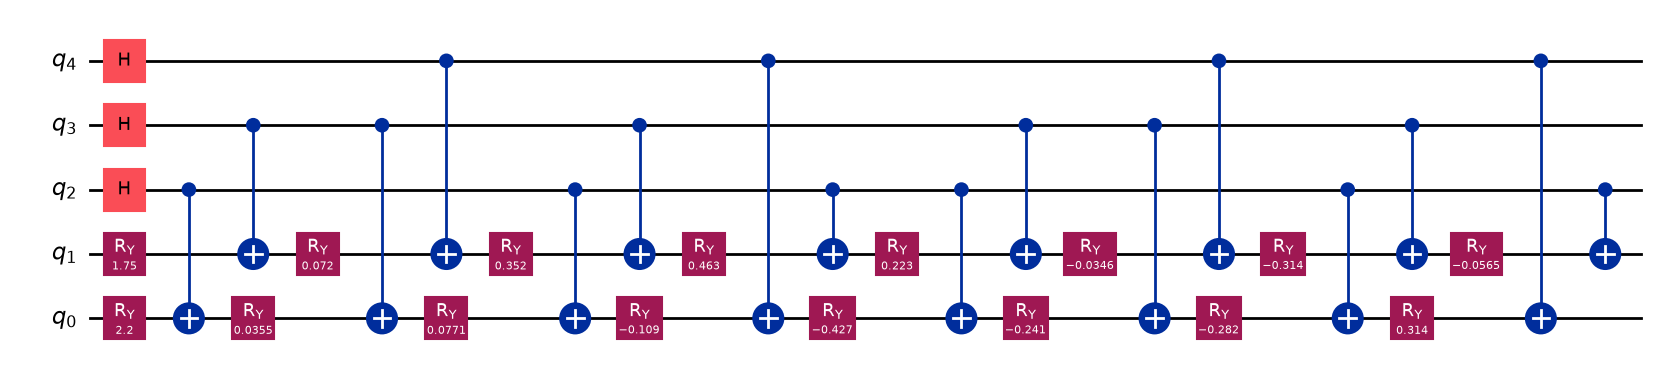

OrderedDict({'ry': 16, 'cx': 16, 'h': 3})
Circuit depth: 16
Circuit width: 5


In [9]:
display(
    circuit.draw(
        output="mpl",        # Render as a Matplotlib figure.
        fold=-1,             # Keep the circuit on one horizontal line.
        reverse_bits=True,   # Display q0 at the bottom; computation is unchanged.
    )
)

# Print the gate count
print(circuit.count_ops())

# Print depth and width of the circuit
print(f"Circuit depth: {circuit.depth()}")
print(f"Circuit width: {circuit.width()}")

## 10. Compare the original and decoded signals

For the uncompressed ideal statevector simulation, the original and decoded
curves should overlap in every channel. Raising the compression percentage will
generally remove small elementary rotations but introduce reconstruction error.

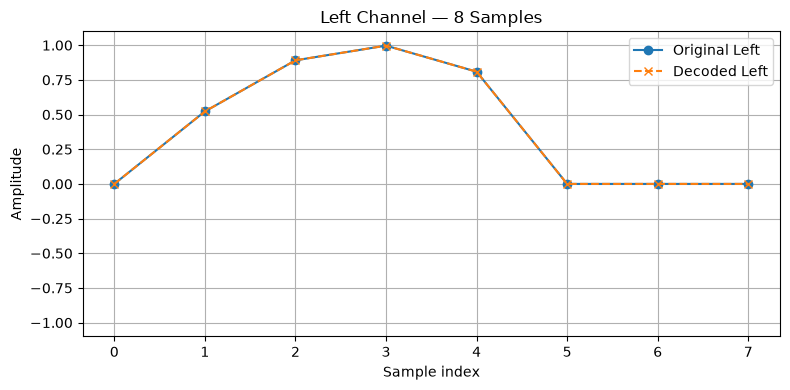

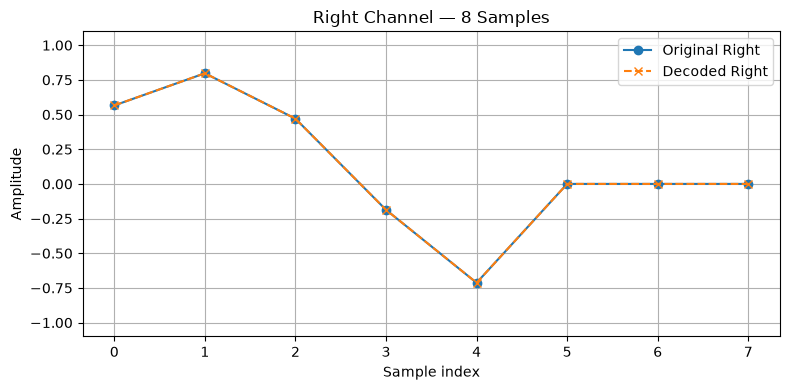

In [10]:
# Use integer sample positions on the horizontal axis.
sample_indices = np.arange(zero_padded_signal.shape[0])
channel_names = ["Left", "Right"]

for channel in range(zero_padded_signal.shape[1]):
    name = (
        channel_names[channel]
        if channel < len(channel_names)
        else f"Channel {channel}"
    )

    plt.figure(figsize=(8, 4))
    plt.plot(
        sample_indices,
        zero_padded_signal[:, channel],
        "o-",
        label=f"Original {name}",
    )
    plt.plot(
        sample_indices,
        decoded_signal[:, channel],
        "x--",
        label=f"Decoded {name}",
    )

    plt.title(f"{name} Channel — {zero_padded_signal.shape[0]} Samples")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.xticks(sample_indices)
    plt.ylim(-1.1, 1.1)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 11. Notes

- **One data qubit per channel:** this notebook assigns each audio channel to one
  data qubit. Stereo therefore uses two data qubits.
- **Shared address register:** all channels use the same time-sample addresses.
  At address $j$, the data qubits jointly encode all channel samples at that time.
- **Parallel QCrank structure:** cyclically permuted channel UCRs allow rotations
  on different data qubits and CNOTs on disjoint address–data pairs to be
  scheduled concurrently.
- **Ideal simulation:** decoding uses exact statevector probabilities. Real
  hardware would require measurements, repeated shots, marginal probability
  estimates, and possibly calibration or error mitigation.
- **Power-of-two length:** the signal is zero-padded to have $N=2^{n_a}$ samples per channel.
- **Equal channel lengths:** every channel must contain the same number of
  samples because all channels share one address register.
- **Compression domain:** compression zeroes small transformed rotation
  coefficients. It does not remove input samples and does not reduce the number
  of qubits.
- **Compression and CNOTs:** zero rotations are omitted, but the full cyclic CNOT
  network is retained to keep the pUCR structure explicit.
- **Probability-based decoding:** the $[0,\pi]$ angle interval is important
  because the decoder does not retain arbitrary amplitude signs or phases.
- **Channel ordering:** column `c` of the classical audio array maps to data
  qubit `qc`.
- **Statevector cost:** the exact statevector dimension is
  $2^{n_a+n_d}=N\,2^{n_d}$, so simulation cost grows with both the number of
  samples and the number of channels.